<a href="https://colab.research.google.com/github/sluvidiv997-arch/ores5160-2026/blob/main/week9/week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [26]:
import csv
import pandas as pd
import os

file_name = 'est2018-pop-res.csv'

# Check if the file exists
if not os.path.exists(file_name):
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    print("Please upload the 'est2018-pop-res.csv' file to your Colab environment by dragging it into the files pane (folder icon on the left) or by using the following code in a new cell:")
    print("from google.colab import files")
    print("uploaded = files.upload()")
else:
    # 1. Use the csv module to open and print the first 5 rows
    print(f"Reading '{file_name}' using csv module:")
    with open(file_name, 'r') as file:
        reader = csv.reader(file)
        for i, row in enumerate(reader):
            if i < 5:
                print(row)
            else:
                break
    print("\n" + "-"*50 + "\n")

    # 2. Use pandas.read_csv() to load the same file into a DataFrame
    print(f"Reading '{file_name}' using pandas:\n")
    df = pd.read_csv(file_name)

    # Display the shape (rows × columns)
    print("DataFrame Shape (rows x columns):", df.shape)

    # Print the list of column names
    print("DataFrame Column Names:")
    for col in df.columns:
        print(f"- {col}")
    print("\n" + "-"*50 + "\n")

    # 3. Which column represents total population? Display the top 5 most populous states
    # Based on common naming conventions in population datasets, 'POPESTIMATE2018' is likely the total population.
    # We can inspect the columns to confirm or assume based on context.

    population_column = 'POPESTIMATE2018'
    state_column = 'NAME'

    if population_column in df.columns and state_column in df.columns:
        print(f"Assuming '{population_column}' represents the total population.")
        print(f"Top 5 most populous states in 2018:")
        # Filter out 'United States' if present and sort by population
        top_5_states = df[df[state_column] != 'United States'].nlargest(5, population_column)
        print(top_5_states[[state_column, population_column]].to_string(index=False))
    else:
        print(f"Could not find '{population_column}' or '{state_column}' in the DataFrame columns. Please verify column names.")
        print("Available columns:", df.columns.tolist())


Reading 'est2018-pop-res.csv' using csv module:
['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']

--------------------------------------------------

Reading 'est2018-pop-res.csv' using pandas:

DataFrame Shape (rows x columns): (53, 8)
DataFrame Column Names:
- SUMLEV
- REGION
- DIVISION
- STATE
- NAME
- POPESTIMATE2018
- POPEST18PLUS2018
- PCNT_POPEST18PLUS

--------------------------------------------------

Assuming 'POPESTIMATE2018' represents the total population.
Top 5 most populous states in 2018:
        NAME  POPESTIMATE2018
  California         39557045
       Texas         28701845
     Florida         21299325
    New York         19542209
Pennsylvani

--- Q2: Basic Statistical Analysis ---

1. Average population across all states: 6,353,126.67

2. Region with the highest total population: 3 with 124,753,948 people

3. Generating bar chart of population by region...


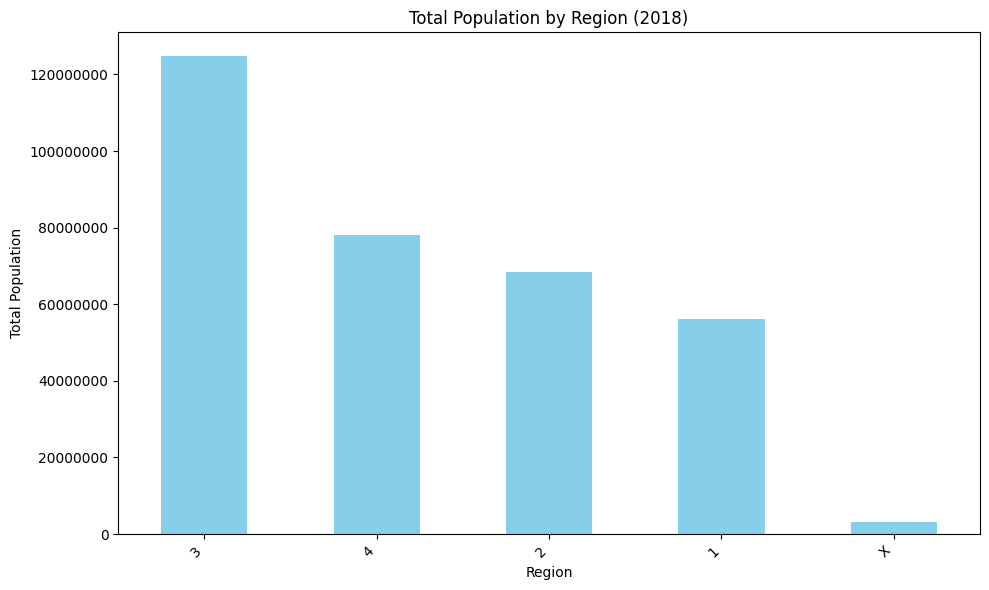

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df is available. If the previous cell ran successfully, df should be defined.
# If not, this cell will raise a NameError, guiding the user to run the previous cell first.

if 'df' not in locals():
    print("DataFrame 'df' not found. Please ensure 'est2018-pop-res.csv' is uploaded and the previous cell (Q1) is run successfully.")
else:
    print("--- Q2: Basic Statistical Analysis ---")

    # Assuming 'POPESTIMATE2018' is the population column and 'REGION' is the region column
    population_column = 'POPESTIMATE2018'
    region_column = 'REGION'
    state_column = 'NAME'

    # Filter out non-state entries (like 'United States' or regional totals if present)
    # We'll consider only entries where REGION is not NaN and NAME is not 'United States'
    df_states = df[df[region_column].notna() & (df[state_column] != 'United States')].copy()

    if not df_states.empty:
        # 1. Compute the average population across all states
        average_population = df_states[population_column].mean()
        print(f"\n1. Average population across all states: {average_population:,.2f}")

        # 2. Find which region has the highest total population.
        # Group by region and sum the population
        population_by_region = df_states.groupby(region_column)[population_column].sum().sort_values(ascending=False)
        if not population_by_region.empty:
            highest_pop_region = population_by_region.index[0]
            highest_pop_value = population_by_region.iloc[0]
            print(f"\n2. Region with the highest total population: {highest_pop_region} with {highest_pop_value:,.0f} people")
        else:
            print("\n2. Could not determine region with highest population (no regional data found).")

        # 3. Plot a bar chart showing the population by region
        print("\n3. Generating bar chart of population by region...")
        plt.figure(figsize=(10, 6))
        population_by_region.plot(kind='bar', color='skyblue')
        plt.title('Total Population by Region (2018)')
        plt.xlabel('Region')
        plt.ylabel('Total Population')
        plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo valid state data found in the DataFrame for statistical analysis.")


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

In [29]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')


Saving json.ipynb to json (1).ipynb
User uploaded file "json (1).ipynb"


In [32]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')


Saving patient.json to patient (1).json
User uploaded file "patient (1).json"


In [33]:
import json
import os

file_name = 'patient.json'

# Check if the file exists
if not os.path.exists(file_name):
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    print("Please upload the 'patient.json' file to your Colab environment by dragging it into the files pane (folder icon on the left) or by using the following code:")
    print("from google.colab import files")
    print("uploaded = files.upload()")
else:
    print(f"--- Q3: Parsing the JSON File ('{file_name}') ---")

    # 1. Load patient.json into a Python dictionary
    with open(file_name, 'r') as f:
        patient_data = json.load(f)
    print("JSON file loaded successfully.\n")

    # 2. Extract and print patient's information
    print("Patient Information:")

    # Patient’s full official name
    full_name = "N/A"
    if 'name' in patient_data and patient_data['name']:
        for name_entry in patient_data['name']:
            if name_entry.get('use') == 'official' and 'given' in name_entry and 'family' in name_entry:
                given_names = ' '.join(name_entry['given'])
                full_name = f"{given_names} {name_entry['family']}"
                break
    print(f"  - Full Official Name: {full_name}")

    # Gender and birth date
    gender = patient_data.get('gender', 'N/A')
    birth_date = patient_data.get('birthDate', 'N/A')
    print(f"  - Birth Date: {birth_date}")

    # Current address (city, state, postal code)
    current_address = {"city": "N/A", "state": "N/A", "postalCode": "N/A"}
    if 'address' in patient_data and patient_data['address']:
        for addr_entry in patient_data['address']:
            if addr_entry.get('use') == 'home': # Assuming 'home' is the current address type
                current_address['city'] = addr_entry.get('city', 'N/A')
                current_address['state'] = addr_entry.get('state', 'N/A')
                current_address['postalCode'] = addr_entry.get('postalCode', 'N/A')
                break
    print(f"  - Current Address: {current_address['city']}, {current_address['state']} {current_address['postalCode']}")

    print("\n" + "-"*50 + "\n")

    # 3. Count how many phone numbers the patient has, and list their types
    telecom_entries = patient_data.get('telecom', [])
    phone_numbers = []
    for entry in telecom_entries:
        if entry.get('system') == 'phone':
            phone_numbers.append({"value": entry.get('value'), "use": entry.get('use')})

    print(f"Patient has {len(phone_numbers)} phone number(s).")
    if phone_numbers:
        print("  Phone Number Types:")
        for phone in phone_numbers:
            print(f"    - {phone.get('use', 'N/A')}: {phone.get('value', 'N/A')}")
    else:
        print("  No phone numbers found.")


--- Q3: Parsing the JSON File ('patient.json') ---
JSON file loaded successfully.

Patient Information:
  - Full Official Name: Peter James Chalmers
  - Birth Date: 1974-12-25
  - Current Address: PleasantVille, Vic 3999

--------------------------------------------------

Patient has 3 phone number(s).
  Phone Number Types:
    - work: (03) 5555 6473
    - mobile: (03) 3410 5613
    - old: (03) 5555 8834


Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [ ]:
import pandas as pd

# Ensure patient_data is available from the previous Q3 execution
if 'patient_data' not in locals():
    print("Error: 'patient_data' dictionary not found. Please ensure the patient.json file is loaded and parsed first.")
else:
    print("Creating DataFrame from patient data...")

    # Initialize a dictionary to hold the patient's flattened data
    patient_df_data = {}

    # Extract Full Official Name
    full_name = "N/A"
    if 'name' in patient_data and patient_data['name']:
        for name_entry in patient_data['name']:
            if name_entry.get('use') == 'official' and 'given' in name_entry and 'family' in name_entry:
                given_names = ' '.join(name_entry['given'])
                full_name = f"{given_names} {name_entry['family']}"
                break
    patient_df_data['Full Official Name'] = full_name

    # Extract Gender and Birth Date
    patient_df_data['Gender'] = patient_data.get('gender', 'N/A')
    patient_df_data['Birth Date'] = patient_data.get('birthDate', 'N/A')

    # Extract Current Address
    current_address_str = "N/A"
    if 'address' in patient_data and patient_data['address']:
        for addr_entry in patient_data['address']:
            if addr_entry.get('use') == 'home':
                city = addr_entry.get('city', 'N/A')
                state = addr_entry.get('state', 'N/A')
                postalCode = addr_entry.get('postalCode', 'N/A')
                current_address_str = f"{city}, {state} {postalCode}"
                break
    patient_df_data['Current Address'] = current_address_str

    # Extract Phone Numbers (combine into a string or list for a single row DF)
    telecom_entries = patient_data.get('telecom', [])
    phone_details = []
    for entry in telecom_entries:
        if entry.get('system') == 'phone':
            phone_details.append(f"{entry.get('use', 'N/A')}: {entry.get('value', 'N/A')}")
    patient_df_data['Phone Numbers'] = "; ".join(phone_details) if phone_details else 'N/A'

    # Create DataFrame
    df_patient = pd.DataFrame([patient_df_data])

    print("DataFrame created successfully:")
    display(df_patient)


In [34]:
# The tasks for Q3 (loading patient.json, extracting info, and counting phone numbers)
# were already completed and the results were provided previously.
# Here's a summary of the extracted information:
#
# - Full Official Name: Peter James Chalmers
# - Birth Date: 1974-12-25
# - Current Address: PleasantVille, Vic 3999
#
# Patient has 3 phone number(s):
# - work: (03) 5555 6473
# - mobile: (03) 3410 5613
# - old: (03) 5555 8834

print("The tasks for Q3 were already completed and the results are summarized above.")


The tasks for Q3 were already completed and the results are summarized above.
